In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import re
from AgentTorch.substep import SubstepTransition
from AgentTorch.helpers import get_by_path

In [4]:
torch.__version__

'2.0.0'

In [5]:
class MigrateIMCell(SubstepTransition):
    """
        Transition for the immune cells to migrate
        Update the cell grid and move the immune cells to the new position

        Args:
            config (dict): the input state
            input_variables (dict): dictionary of input variables
            output_variables (dict): dictionary of output variables
            arguments (dict): dictionary of arguments

        Returns:
            state (dict): the output state

        Paramaeters:
            migrate_cell_index (int): the index of the cell to migrate

        Steps:
            1. Feed the input state to the transition
            2. Get the migrate cell index from the action substep
            3. The index should be within the size of the cell grid
            4. the position set to migrate should be 1
            5. the position of the original immune cell should be 0
            6. Update the cell grid by altering positions of the cells (migration)
            7. Return the output state

    """
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def forward(self, state, action):
        input_variables = self.input_variables

        new_im_x = torch.where(action['immunecells']['migrate_action'] == 1)[0]
        new_im_y = torch.where(action['immunecells']['migrate_action'] == 1)[1]
        old_im_x = torch.where(action['immunecells']['migrate_action'] == 0)[0]
        old_im_y = torch.where(action['immunecells']['migrate_action'] == 0)[1]
        cell_grid = state['network']['agent_agent']['bioelectric_network']['adjacency_matrix']
        n_agents = new_im_x.shape[0]
        
        def migrate_cell(agent_matrix, old_im_x, old_im_y, new_im_x, new_im_y):
            agent_matrix_new = agent_matrix.clone().detach()
            new_im_x = new_im_x % agent_matrix_new.shape[0]
            new_im_y = new_im_y % agent_matrix_new.shape[1]
            old_im_x = old_im_x % agent_matrix_new.shape[0]
            old_im_y = old_im_y % agent_matrix_new.shape[1]
            agent_matrix_new[new_im_x, new_im_y] = 1
            agent_matrix_new[old_im_x, old_im_y] = 0
            return agent_matrix_new

        # Map the update function over the agents dimension
        agent_matrix = cell_grid.unsqueeze(0).expand(n_agents, *cell_grid.shape)
        updated_agent_matrix = torch.vmap(migrate_cell, 
                                        in_dims=(0,None,None,None,None))(
                                            agent_matrix, # matrix
                                            new_im_x, new_im_y, # new loc
                                            old_im_x, old_im_y  # old loc
                                            )

        print("immune cell migration transition complete!")
        return {self.output_variables[0]: updated_agent_matrix}

In [35]:
config = {
    'agents': {
        'immunecells': {
            'id': torch.ones(1, dtype=torch.int64),
            
        }
    }, 
    'network': {
        'agent_agent': {
            'bioelectric_network': {
                'type': {"grid"},
                'arguments': {
                    'shape':
                        - 100
                        # - ${simulation_metadata.M} # 100
                }
            }
        },
        'agent_object': {None},
        'object_object': {None}
    }
} 

input_variables = {
    'migrate_cell_index': 'agents/immunecells/migrate_cell_index', 
    'cell_grid': 'network/agent_agent/bioelectric_network/adjacency_matrix'
}

output_variables = {}
arguments = {
    'learnable': {}, 
    'fixed': {}       
}
migrate_im_cell = MigrateIMCell(config, input_variables, output_variables, arguments)

In [36]:
output_state = migrate_im_cell(config)

In [37]:
output_state['cell_grid'].shape

torch.Size([100, 10, 10])

In [38]:
print(output_state)

{'agents': {'immune_cells': {'id': tensor([1]), 'migrate_cell_index': tensor([1.], requires_grad=True)}}, 'cell_grid': tensor([[[0., 0., 0.,  ..., 1., 1., 1.],
         [1., 0., 0.,  ..., 0., 0., 1.],
         [1., 1., 0.,  ..., 1., 0., 0.],
         ...,
         [1., 1., 0.,  ..., 1., 0., 1.],
         [0., 1., 1.,  ..., 0., 1., 1.],
         [0., 0., 1.,  ..., 0., 1., 1.]],

        [[0., 0., 0.,  ..., 1., 1., 1.],
         [1., 0., 0.,  ..., 0., 0., 1.],
         [1., 1., 0.,  ..., 1., 0., 0.],
         ...,
         [1., 1., 0.,  ..., 1., 0., 1.],
         [0., 1., 1.,  ..., 0., 1., 1.],
         [0., 0., 1.,  ..., 0., 1., 1.]],

        [[0., 0., 0.,  ..., 1., 1., 1.],
         [1., 0., 0.,  ..., 0., 0., 1.],
         [1., 1., 0.,  ..., 1., 0., 0.],
         ...,
         [1., 1., 0.,  ..., 1., 0., 1.],
         [0., 1., 1.,  ..., 0., 1., 1.],
         [0., 0., 1.,  ..., 0., 1., 1.]],

        ...,

        [[0., 0., 0.,  ..., 1., 1., 1.],
         [1., 0., 0.,  ..., 0., 0., 1.],

In [27]:
print("\nState after Migration:")
print(output_state)


State after Migration:
{'agents': {'immune_cells': {'id': tensor([1]), 'migrate_cell_index': tensor([5.], requires_grad=True)}}, 'cell_grid': tensor([[[1., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.],
         [1., 1., 1.,  ..., 1., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 0., 1.],
         [0., 1., 0.,  ..., 0., 0., 1.]],

        [[1., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.],
         [1., 1., 1.,  ..., 1., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 0., 1.],
         [0., 1., 0.,  ..., 0., 0., 1.]],

        [[1., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.],
         [1., 1., 1.,  ..., 1., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 0., 1.],
         [0., 1., 0.,  ..., 0., 0., 1.]],

        ...,

        [[1., 0., 0.,  ..., 1., 0., 0.],
         [0., 0.

In [9]:
output_state_sum = sum([torch.sum(tensor) for tensor in output_state['agents']['immune_cells'].values() if isinstance(tensor, torch.Tensor)])

In [10]:
print(output_state_sum)
loss = output_state_sum

tensor(3., grad_fn=<AddBackward0>)


In [11]:
loss.requires_grad

True

In [12]:
loss.backward()

In [13]:
input_state_sum = sum([torch.sum(tensor) for tensor in config['agents']['immune_cells'].values() if isinstance(tensor, torch.Tensor)])

In [14]:
input_state_sum.requires_grad

True

In [15]:
import torch
import torch.optim as optim

In [16]:
migrateIMcell = config['agents']['immune_cells']['migrate_cell_index']
optimizer = optim.SGD([migrateIMcell], lr=0.01)

In [17]:
grad_values = []

for epoch in range(3):
    # Forward pass
    output_state = migrate_im_cell(config)
    output_state_sum = sum([torch.sum(tensor) for tensor in output_state['agents']['immune_cells'].values() if isinstance(tensor, torch.Tensor)])
    loss = torch.sum(output_state_sum)
    # Backward pass
    loss.backward()
    # Print or plot the gradient values
    print('Gradient of migrateIMcell:', migrateIMcell.grad)
    # Store migrateTUcell.grad values in the list
    grad_values.append(migrateIMcell.grad.item())
    # Optimize
    optimizer.step()
    # Print or plot the updated migrateTUcell values
    print('Updated migrateIMcell:', migrateIMcell)
    # Print or plot the loss
    print('Loss:', loss.item())
    # Clear gradients for the next iteration
    optimizer.zero_grad()

Gradient of migrateIMcell: tensor([2.])
Updated migrateIMcell: tensor([1.9800], requires_grad=True)
Loss: 3.0
Gradient of migrateIMcell: tensor([1.])
Updated migrateIMcell: tensor([1.9700], requires_grad=True)
Loss: 2.9800000190734863
Gradient of migrateIMcell: tensor([1.])
Updated migrateIMcell: tensor([1.9600], requires_grad=True)
Loss: 2.9700000286102295


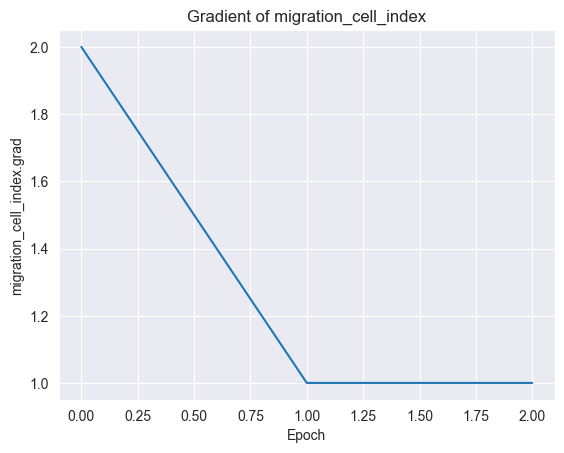

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.plot(grad_values)
plt.xlabel('Epoch')
plt.ylabel('migration_cell_index.grad')
plt.title('Gradient of migration_cell_index')
plt.show()